# **Geophysics Lab 6: Gravity**
Name: Firstname Lastname

**If you don't put your name in both the spot above AND the filename, you will not receive a grade for this lab.** Double-click this cell to add your name, run the cell when you're done. In the filename, please **do not** put any spaces between words or wildcard characters. I will not be grading labs in different file formats or with spaces/wildcards in the file names.

In [ ]:
# run this cell to import some of the packages needed to complete this lab:
import numpy as np               # more on numpy here:       https://numpy.org/doc/stable/user/absolute_beginners.html
import matplotlib.pyplot as plt  # more on matplotlib here:  https://matplotlib.org/stable/users/explain/quick_start.html
import pandas as pd              # more on pandas here:      https://pandas.pydata.org/docs/

This lab will require you to import the data file `GravityData.txt` and use it. **Please make sure that you have downloaded the data file and put it into the same folder as this lab** (you need to do this so I don't have to re-path everyone's code when I grade it). Do NOT submit the data file for grading.

In [ ]:
########## !!!         PLEASE try to INSTALL harmonica before you start the lab         !!! ##########
########## !!!    (installing harmonica SHOULD automatically install verde for you)     !!! ##########
########## !!! this cell will NOT work if you don't already have the packages installed !!! ##########

# we are importing some other packages 'early' to see if you will have any issues with imports in this lab:
import harmonica as hm           # more on harmonica here:   https://www.fatiando.org/harmonica/latest/index.html
import verde as vd               # more on verde here:       https://www.fatiando.org/verde/latest/

# if this cell returns an error, you might not have the necessary packages installed. 
# if you can't figure out the installation, please contact your TA ASAP!

In this lab, we will be using `harmonica` and `verde` to explore the subsurface for first an idealized scenario, and then using some data. This lab consists of three sections with questions for you to answer throughout all sections. <span style="background-color: pink;">**Please make sure you read and address ALL parts of each question**</span>.

## Section 1: Theory and Corrections
**Question 1.1:** \
What does the **Bouguer correction** correct for? _(1 point)_

_Double-click this cell and replace this text with your answers to Question 1.1. Run the cell when you're done._

**Question 1.2:** \
The density of the surrounding rock is 2600 $kg/m^3$ and the density of a body of interest is 2800 $kg/m^3$. What is the **density contrast** in $kg/m^3$? (Make sure you get the sign right.) Store your answer as `contrast_12` below. _(1 point)_

In [ ]:
contrast_12 = ... # replace the ... with your response to Question 1.2 in [kg/m^3]
contrast_12

## Section 2: Using Harmonica
**Harmonica** is a Python library for processing and modeling gravity and magnetic data. It includes common processing steps, like calculation of Bouguer and terrain corrections, reduction to the pole, upward continuation, equivalent sources, and more. There are forward modeling functions for basic geometric shapes. You can find more documentation about Harmonica here: https://www.fatiando.org/harmonica/v0.6.0/

To use Harmonica, we first need to define the coordinate system for observation (Harmonica uses a **3-dimensional coordinate system**). Scripts below define a `region` of 100x100 meters: 100 meters in both x and y direction (horizontal). The `shape` parameter defines how many points to measure in the defined region, which in this case, 101 measurement in both x and y direction. Then we would have gravity measurement at `x = [0,1,2,...,100]` and `y = [0,1,2,...,100]`. We also define the height where the measurement _should_ be made, which is important for gravity modeling.

In [ ]:
region      = (0, 100, 0, 100)  # (x_min, x_max, y_min, y_max), all in meters
shape       = (101, 101)        # (n_x, n_y)
height      = 0                 # height where the measurement should be made, in meters
coordinates = vd.grid_coordinates(region, shape=shape, extra_coords=height)

Then, we define the density model that gives gravity response. Here, we define a 3-dimensional block with some density contrast to the background. **Harmonica assumes zero density of the background material, so when defining the body, only use the density constrast.** 

For example here, we define a block that is 20 meters width in x (left edge at 40 $m$, right edge at 60 $m$), 20 meters width in y (left edge at 40 $m$, right edge at 60 $m$), and 10 meters thick (upper edge at -10 $m$, lower edge at -20 $m$). The density contrast is 200 $kg/m^3$.

In [ ]:
block            = [40, 60, 40, 60, -20, -10] # (x_min, x_max, y_min, y_max, z_min, z_max), all in meters
density_contrast = 200.                       # unit in kg/m^3

Using the parameters above, we can model the gravity field anomaly ($g_z$) from the higher density block.

In [ ]:
result_q21 = hm.prism_gravity(coordinates, block, density_contrast, field="g_z")
print(f"the shape of result is {result_q21.shape}")

We can plot the gravity anomaly in map view (2D). We can also plot the **anomaly profile** (1D, along the lines shown in the map below).

In [ ]:
plt.figure(figsize=(14, 5), dpi=200)
plt.subplot(1,2,1)
plt.title("gravity anomaly in map view")
plt.pcolormesh(coordinates[0], coordinates[1], result_q21)
plt.hlines(50, 1, 100, color='white', linestyle='--')
plt.hlines(30, 1, 100, color='white', linestyle='-.')
plt.hlines(10, 1, 100, color='white', linestyle=':')
plt.text(12,52, 'A',color='white')
plt.text(12,32, 'B',color='white')
plt.text(12,12, 'C', color='white')
plt.colorbar(label="mGal")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1,2,2)
plt.title("gravity anomaly profile")
plt.plot(result_q21[50], color='k', linestyle='-',label='Line 1')
plt.plot(result_q21[30], color='k', linestyle=':',label='Line 2')
plt.plot(result_q21[10], color='k', linestyle='--',label='Line 3')
plt.legend()
plt.xlabel("x")
plt.show();

**Question 2.1:** \
_(1.5 points)_
1. Describe the shape of the curve in the gravity anomaly profile.

2. The solid line (Line 1) on the profile plot corresponds to which profile on the map (A, B, C)? How about the dotted line (Line 2) and the dashed line (Line 3)?

3. Where is the peak of the curve relative to the block?

_Double-click this cell and replace this text with your answers to Question 2.1. Run the cell when you're done._

**Question 2.2:** \
Give your answers based on the anomaly map. You can use `np.max()` to fine the maximum value in the `result_q21`. _(1 point)_

1. What is the peak anomaly when the density contrast is 200 $kg/m^3$?

2. If you change the contrast density to 100 $kg/m^3$, what will be the peak anomaly?

In [ ]:
# your code here to address Question 2.2

_Double-click this cell and replace this text with your answers to Question 2.2. Run the cell when you're done._

**Question 2.3:** \
_(1 point)_
1. What happens to the curve if you change the density contrast to negative?

2. If the density contrast is negative, is the body more or less dense than the surrounding host rock?

_Double-click this cell and replace this text with your answers to Question 2.3. Run the cell when you're done._

**Question 2.4:** \
Remember that we modeled the gravity anomaly for a block with density contrast of $200 kg/m^3$. Now, increase the density contrast to 400 $kg/m^3$. Approximately how deep does **the top of the body** (z_max) have to be for the peak anomaly to be the same as it was when the density contrast was 200 $kg/m^3$?  _(1 point)_\
_You can modify the depth of the block below, but **please keep the thickness of the body at a constant** 10 $m$._

In [ ]:
# don't change these values
region      = (0, 100, 0, 100)  # (x_min, x_max, y_min, y_max), all in meters
shape       = (101, 101)        # (n_x, n_y)
height      = 0                 # height where the measurement should be made, in meters -- don't change this
coordinates = vd.grid_coordinates(region, shape=shape, extra_coords=height) 

# change these values to address Question 2.4:
block_24         = [40, 60, 40, 60, ..., ...] # (x_min, x_max, y_min, y_max, z_min, z_max), all in meters
density_contrast = ...                        # float [kg/m^3]

# this will calculate and show the maximum gravity anomaly
result_q24 = hm.prism_gravity(coordinates, block_24, density_contrast, field="g_z")
print(f"the maximum gravity anomaly is {np.max(result_q24)} mGal")

_Double-click this cell and replace this text with your answers to Question 2.4. Run the cell when you're done._

**Question 2.5:** \
Now reduce the density contrast to 150 $kg/m^3$. Approximately how shallow does **the top of the body** (z_max) have to be for the peak anomaly to be the same as it was when the density contrast was 200 $kg/m^3$? _(1 point)_ \
_You can modify the depth of the block below, but **please keep the thickness of the body at a constant** 10 $m$._

In [ ]:
# change these values to address Question 2.5
block_25         = [40, 60, 40, 60, ..., ...] # (x_min, x_max, y_min, y_max, z_min, z_max), all in meters
density_contrast = ...                        # float [kg/m^3]

# this will calculate and show the maximum gravity anomaly
result_q25 = hm.prism_gravity(coordinates, block_25, density_contrast, field="g_z")
print(f"the maximum gravity anomaly is {np.max(result_q25)} mGal")

_Double-click this cell and replace this text with your answers to Question 2.5. Run the cell when you're done._

**Question 2.6:** \
We plot the anomaly profile from `result_q21` (corresponds to contrast 200 $kg/m^3$), together with `result_q24` and `result_q25` (corresponds to density contrast 400 and 150 $kg/m^3$, respectively). Use the figure below to explain how can you distinguish a shallow, dense body from a deeper, denser body. _(1 point)_

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(result_q21[50, :], c='k', linestyle = '-', label=f"z_max = {block[5]}")
plt.plot(result_q24[50, :], c='k', linestyle = '--', label=f"z_max = {block_24[5]}")
plt.plot(result_q25[50, :], c='k', linestyle = ':', label=f"z_max = {block_25[5]}")
plt.grid()
plt.legend()
plt.xlabel("y (m)", fontsize=14)
plt.ylabel("gravity anomaly (mGal)", fontsize=14)
plt.show();

_Double-click this cell and replace this text with your answer to Question 2.6. Run the cell when you're done._

## Section 3: Using Gravity Data
Based on your answer the previous section, you should have noticed that the results from gravity surveys are non-unique. Multiple subsurface configurations can produce very similar anomaly curves!

**Question 3.1:** \
Load the file `GravityData.txt`. **Create two different subsurface models to fit the observations** (i.e., add bodies to the subsurface so that the calculated gravities fit the observations). You can use different density contrasts, shapes, and even add more than 1 body. There are infinite answers. _(2 points)_

In [ ]:
# read in the data
df = pd.read_csv(..., names=["measurement", "x", "g_z"]) # get the data file in there 
df.head()

In [ ]:
# use the same coordinate system as in section 2
region      = (0, 100, 0, 100)  # (x_min, x_max, y_min, y_max), all in meters
shape       = (101, 101)        # (n_x, n_y)
height      = 0                 # height where the measurement should be made, in meters
coordinates = vd.grid_coordinates(region, shape=shape, extra_coords=height)

For the first model, you can try to fit the data using one block. To simplify the model, we fix y_min = 0 and y_max = 100 to approximate a 2D case.

In [ ]:
# Type your answer here, replacing "..." with your answer
blocks           = [..., ..., 0, 100, ..., ...]   # (x_min, x_max, y_min, y_max, z_min, z_max), all in meters
density_contrast = ...                            # float [kg/m^3]

result_q31_m1 = hm.prism_gravity(coordinates, blocks, density_contrast, field='g_z')
print(f"the maximum gravity anomaly for the first model is {np.max(result_q31_m1)} mGal")

You can also try to match the data using two blocks, with different locations, density contrasts, and sizes. Play with the parameters below so that the gravity anomaly still matches the data well. 

Again, to simplify the model, we fix `y_min = 0` and `y_max = 100` to approximate a 2D case.

In [ ]:
# Type your answer here, replacing "..." with your answer
blocks = [[..., ..., 0, 100, ..., ...], # (x_min, x_max, y_min, y_max, z_min, z_max) of BLOCK 1
          [..., ..., 0, 100, ..., ...]] # (x_min, x_max, y_min, y_max, z_min, z_max) of BLOCK 2
density = [...,                         # density contrast for BLOCK 1
           ...]                         # density contrast for BLOCK 2

result_q31_m2 = hm.prism_gravity(coordinates, blocks, density, field='g_z')
print(f"the maximum gravity anomaly for the second model is {np.max(result_q31_m2)} mGal")

Plot the modeled gravity anomaly in the figure below. Match your results (`result_q31_m1` and `result_q31_m2`) with the data (`df['g_z']`). Note that you don't need to be 100% accurate, but try to get close.

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['x'], df['g_z'], label = 'data', linewidth = 2)
plt.plot(df['x'], result_q31_m1[50, :], label = 'my model 1')
plt.plot(df['x'], result_q31_m2[50, :], label = 'my model 2')
plt.xlabel("x (m)", fontsize=14)
plt.ylabel("gravity anomaly (mGal)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

**Question 3.2:** \
A company is looking to build a new housing development in northern Arizona. The shallow subsurface in the area is composed of limestone and there has consequently been a history of large sinkholes. The company hires you to perform a gravity survey to look for shallow, underground caverns. 

The subsurface configurations in the figure below produce similar gravity anomaly curves. Which is more geologically plausible? **Justify your answer with two geologic reasons at minimum!** _(2.5 points)_

**Note: The typical density of limestone is 2500-2800 $kg/m^3$.** And the **Density** column in the figure below marks the **density contrast**.

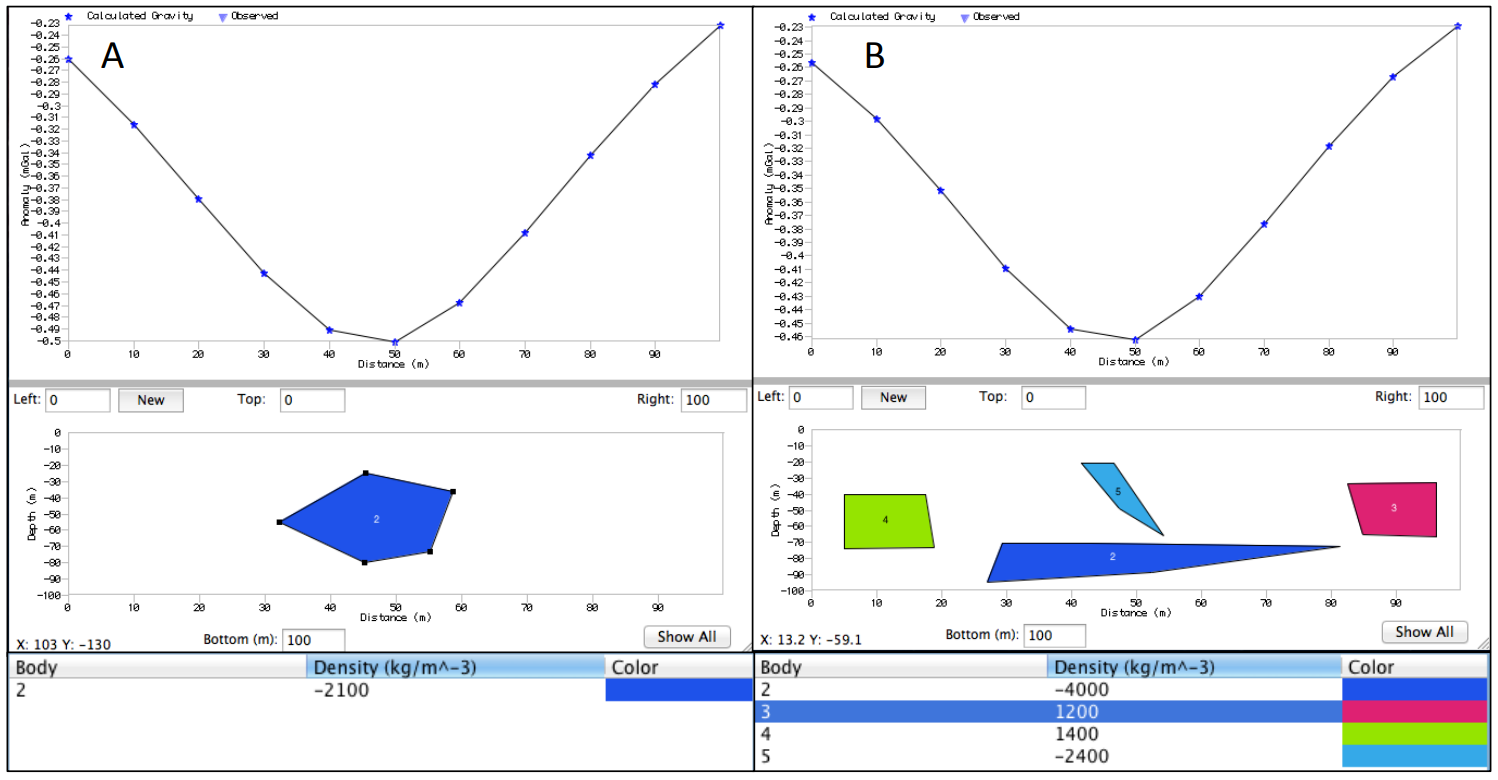

_Double-click this cell and replace this text with your answer to Question 3.2. Run the cell when you're done._

## Section 4: Gravity Survey
In this section of the lab, you will be using location and gravity measurements to estimate gravity anomalies in Johnson Hall and ATG.

**Question 4.1:** \
Navigate to Google Maps in a browser window. _(1 point)_
* Use Google Maps to zoom in on the south ATG stairwell (blue lower dot on the figure below). It's probably best to use the satellite layer. Hover your cursor over the location for the stairwell, and then right-click to get the latitude. Record the latitude with as much accuracy as is provided. Store your latitude value as `LAT_ATG`.
* Do the same for the red dot in below figure (under the arch at the SW corner of JHN 100). This site is just one of six gravity reference sites in WA where absolute gravity is known. Store the latitude for this spot as `LAT_JHN`.

In [ ]:
# Your answer to Question 4.1 here.

These latitudes (in decimal degrees) will be used to correct your observations for the Earth’s rotation and ellipticity. Throughout your analysis, think carefully about the number of significant digits you need to keep. For example, your ability to select the right spot on the map is probably good to about 1 to 10 meters.

**Question 4.2** \
How many decimal places do you need to keep in the latitude to have 10 m accuracy? **Show your work.** Recall that 10000 km = 90 degrees (this was actually the original definition of the meter), so in rough numbers, 1 degree corresponds to 100 km. Use LaTeX formatting in the Markdown cell when showing your work (you can double-click other Markdown cells to see how this type of formatting works). _(1 point)_

_Double-click this cell and replace this text with your answer for Question 4.2. Run the cell when you're done._

**Question 4.3:** \
Write a function to calculate reference gravity using the following equation:
\begin{equation}\tag{4.3.1}
g_n = 978.03185(1 + 0.005278895 \sin^2\phi + 0.000023462 \sin^4\phi)
\end{equation}
where $\phi$ is latitude, $g_n$ is initially in units of $cm/s^2$, and you must convert to mgals by multiplying by 1000. The function should only take in $\phi$, and only output $g_n$. **We will go over this during the lab period.** _(2 points)_

If you want to learn more about Python functions, see here: https://www.w3schools.com/python/python_functions.asp

In [ ]:
# replace the ellipses to answer 4.3

def g_n(...):
    ...
    return ...

**Question 4.4:** \
Call your function from 4.3 to calculate the reference gravity $g_n$ at both ATG and JHN latitudes. Use all of the decimal places. Recall that this is the expected gravity at sea level corrected for Earth’s rotation and ellipticity. Store the reference gravity for ATG as `g_n_atg` and the reference gravity for JHN as `g_n_jhn`, both in units of mgal. **Print both values.** How big is the difference between the two sites? _(2 points)_

In [ ]:
# Your calculations for the first part Question 4.4 here.

_Double-click this cell and replace this text with your answer to the rest of Question 4.4. Run the cell when you're done._ 

**Question 4.5:** \
Call your function from 4.3 to recalculate the reference gravity only using the significant figures determined in Question 4.2. How big is the difference between sites? What does this tell you about the level of accuracy that is needed for location measurements in order to make extremely precise gravity measurements? _(2 points)_

In [ ]:
# You calculations for the first part of Question 4.5 here.

_Double-click this cell and replace this text with your answer to the rest of Question 4.5. Run the cell when you're done._

Now for the fun part: **you** get to measure gravity. You will go with a TA to first the reference site in JHN, and then the ATG stairwell to take measurements with the gravimeter. Read the document `SupplementalGravity-HowTo.pdf` for instructions on how to use the gravimeter. Record your gravimeter readings on the handout given in lab for use here.

**Question 4.6:** \
Store your gravimeter readings by floor below. Then convert the readings to $g_{obs}$ in mgals for each floor. **Show your work** either commented in to your Python calculation or in a new Markdown cell below. Make sure your values for $g_{obs}$ print with the provided print statements. _(2 points)_

In [ ]:
... # record each reading as a variable
...
... # convert readings to g_obs
...

g_obs1 = ... # g_obs for first floor
g_obs3 = ... # g_obs for third floor
g_obs5 = ... # g_obs for fifth floor
g_obs7 = ... # g_obs for seventh floor

print(f"g_obs for first floor is {g_obs1}")
print(f"g_obs for third floor is {g_obs3}")
print(f"g_obs for fifth floor is {g_obs5}")
print(f"g_obs for seventh floor is {g_obs7}")

**Question 4.7:** \
Calculate the gravity anomaly ($g_A$) and Free-air anomaly ($g_{FA}$) for the first, third and fifth floors of ATG. Assume that the ground floor (1) has an elevation of 115 feet and that the distance between each floor is 13 feet, except for floors 4 and 5, where it is 14 feet. Use the below equations:
\begin{equation}\tag{4.7.1}
g_A = g_{obs} - g_n
\end{equation}

\begin{equation}\tag{4.7.2}
g_{FA} = g_A + 0.3086h
\end{equation}
where $h$ is the elevation. Use your work to populate the table below for your answer. _(6 points)_

In [ ]:
# perform your calculations for 4.7 here, and then populate the table below with your answers

_Below table is for your answers. Double-click this cell and replace the ? with your values._

| Floor # :                     | 1           | 3           | 5           | 7           |
| ------------------------------| ----------- | ----------- | ----------- | ----------- |
| Height above first floor [ft] |  ?          |  ?          | ?           |  ?          |
| Height above first floor [m]  |  ?          |  ?          |  ?          |  ?          |
| h (elevation) [m]             |  ?          |  ?          |  ?          |  ?          |
| $g_{obs}$  [mgal]             |  ?          |  ?          |  ?          |  ?          |
| $g_A$ [mgal] (eqn 4.7.1)      |  ?          |  ?          |  ?          |  ?          |
| $g_{FA}$ [mgal] (eqn 4.7.2)   |  ?          |  ?          |  ?          |  ?          |

The gravimeter measures relative gravity with extreme accuracy, but it is not good with absolute gravity. This is mainly because the spring stretches with time. So, the standard practice is to measure gravity at a reference site before and after measuring gravity at your desired sites. Measuring the reference place twice allows you to estimate the drift rate of the gravimeter. You would need to keep track of the time of each measurement so you could correct for the effects of tidal forces from the sun and moon.

**Question 4.8:** \
Calculate the observed vertical gravity gradient in the ATG [mgals/m], e.g.
\begin{equation}\tag{4.8.1}
\frac{dg}{dh} = \frac{g_2 - g_1}{h_2 - h_1}
\end{equation}
where $g_2$ and $g_1$ are a pair of gravity observations [mgal] and $h_2$ and $h_1$ is the difference in their
heights [m]. With 4 observations, you can make 6 unique pairs of estimates of dg/dh. The primary effect to look for is that you are moving away from the center of the Earth as you get higher, so $g$ should be getting smaller as you go higher in elevation. Do your calculations and then populate the table below. _(4 points)_

In [ ]:
# perform your calculations for 4.8 here, and then populate the table below with your answers

_Below table is for your answers. Double-click this cell and replace the ? with your values._
| Floor Pair :                | 1,3      | 3,5      | 5,7      | 1,5      | 1,7      | 3,7      |
| ----------------------------| -------- | -------- | -------- | -------- | -------- | -------- |
| $\frac{dg_A}{dh}$           |  ?       |  ?       |  ?       |  ?       |  ?       |  ?       |
| $\frac{dg_{FA}}{dh}$        |  ?       |  ?       |  ?       |  ?       |  ?       |  ?       |

**Question 4.9:** \
Now take the average of your calculations for (1) $\frac{dg_A}{dh}$ and then (2) $\frac{d g_{FA}}{dh}$. Theoretically the vertical gravity gradient is $-0.3086$ [mgals/m]. How close are your calculations to that value? Theoretically the Free-Air gravity gradient should be zero. How close is your calculation to that value? Are these differences on the order of measurement error ($10^{-2}$)? _(2 points)_

In [ ]:
# take your averages here, and display them with appropriate print statements

_Double-click this cell and replace this text with your answer to the rest of Question 4.9. Run the cell when you're done._ 

### **Submission instructions:** 
Make sure you have run **all** cells in your notebook, in order, before saving and submitting, so that all images/graphs appear in the output in your submission. Save the final version of this notebook with your name in the filename and at the beginning (where there is a spot for it). Upload a copy of your notebook to Canvas. 

**If you need an extension, please request it BEFORE the lab is due. I cannot guarantee an extension for you _unless_ you request before the lab is due.**

This concludes Lab 6. 

_Congrats, you made it!_